# Proyek Analisis Data: Student Performance Factors Dataset
- **Nama:** Muhammad Alif Alferdiansyah
- **Email:** alifalferdiansyah7@gmail.com

## Import Semua Packages/Library yang Digunakan


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

In [2]:
data = pd.read_csv("StudentPerformanceFactors.csv")

### Assessing Data

In [3]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [5]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


 ## cek duplikat pada dataset

In [6]:
print(f'Jumlah data duplicate di dataset  : {data.duplicated().sum()}')


Jumlah data duplicate di dataset  : 0


 ## cek data kosong pada dataset

In [7]:
print(f'Jumlah data kosong di dataset: {data.isnull().sum()}')


Jumlah data kosong di dataset: Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


### Analisis Data dan Prapemrosesan

1. **Data Duplikat**  
   - Dataset telah diperiksa, dan tidak ditemukan data duplikat.

2. **Data Kosong (Missing Values)**  
   - Terdapat nilai kosong (missing values) dalam dataset yang perlu dibersihkan terlebih dahulu. Langkah prapemrosesan seperti imputasi (mean, median, atau metode lain) atau penghapusan baris dengan nilai kosong akan dilakukan untuk menjaga integritas data.


# Cleaning Data

In [8]:
data.dropna(inplace = True)

In [9]:
print(f'Jumlah data kosong di dataset: {data.isnull().sum()}')

Jumlah data kosong di dataset: Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [10]:
top_10_scores = data['Exam_Score'].nlargest(10)
print(top_10_scores)

1525    101
94      100
2425     99
3579     99
4192     98
6347     98
6393     98
529      97
919      97
5966     97
Name: Exam_Score, dtype: int64


In [11]:
data = data[data['Exam_Score'] <= 100]

In [12]:
top_10_scores = data['Exam_Score'].nlargest(10)
print(top_10_scores)

94      100
2425     99
3579     99
4192     98
6347     98
6393     98
529      97
919      97
5966     97
3457     96
Name: Exam_Score, dtype: int64


# EDA

# 4.1 Distribusi Nilai Ujian


In [13]:
data['Exam_Score'].describe()

count    6377.000000
mean       67.246825
std         3.891637
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

Text(0, 0.5, 'Frequency')

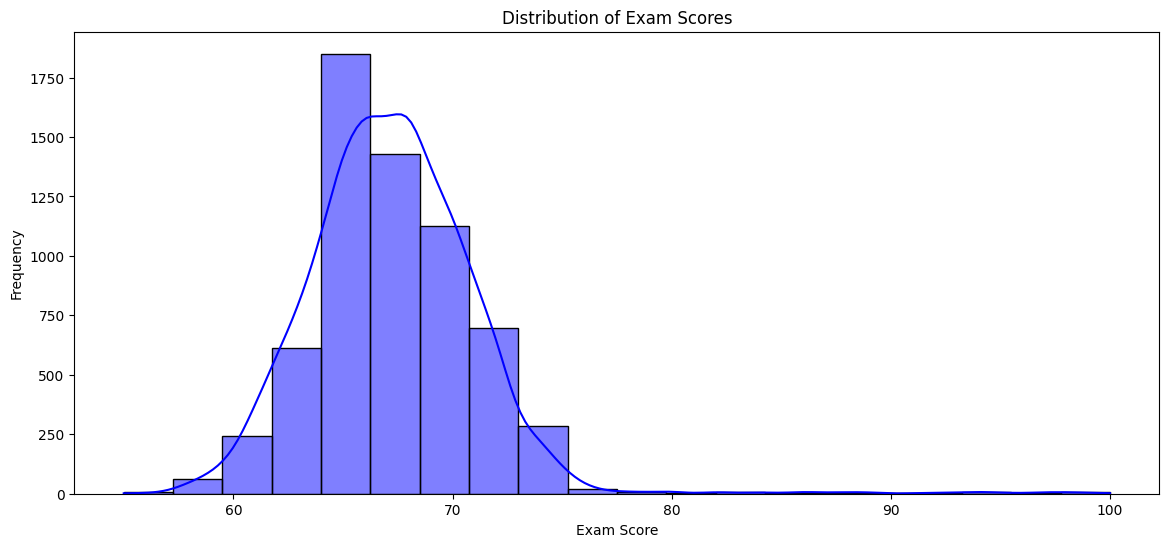

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(data['Exam_Score'], bins=20, kde=True, ax=ax, color='blue')
ax.set_title('Distribution of Exam Scores') 
ax.set_xlabel('Exam Score')            
ax.set_ylabel('Frequency')                    

## 4.2 Analisis Fitur Kategorikal

- **Parental Involvement**
- **Access to Resources**
- **Family Income**
- **Teacher Quality**
- **School Type**
- **Learning Disabilities**
- **Internet Access**
- **Gender**


C:\Users\User\AppData\Local\Temp\ipykernel_19660\2329680327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  countplot = sns.countplot(data=data, x='Parental_Involvement', palette='pastel')


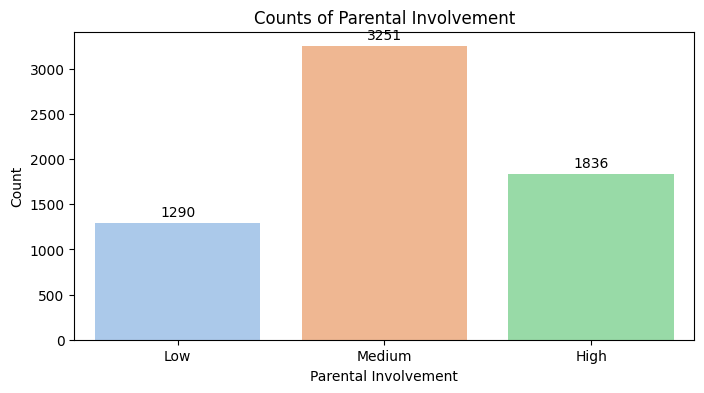

In [51]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Parental_Involvement', palette='pastel')
plt.title('Counts of Parental Involvement')
plt.xlabel('Parental Involvement')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\3175144216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Access_to_Resources', palette='pastel')


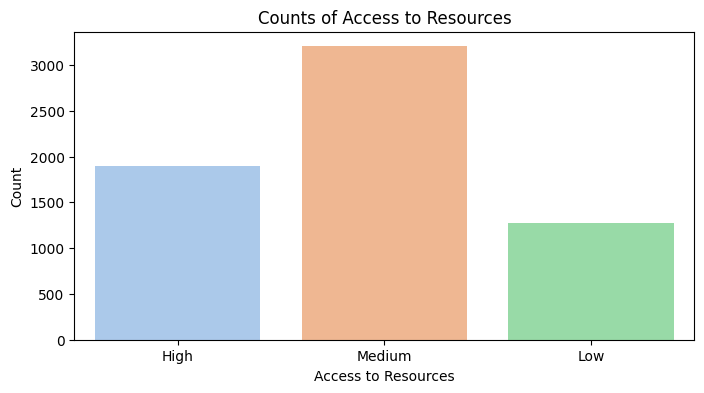

In [49]:
# Access to Resources
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Access_to_Resources', palette='pastel')
plt.title('Counts of Access to Resources')
plt.xlabel('Access to Resources')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\911003534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Family_Income', palette='pastel')


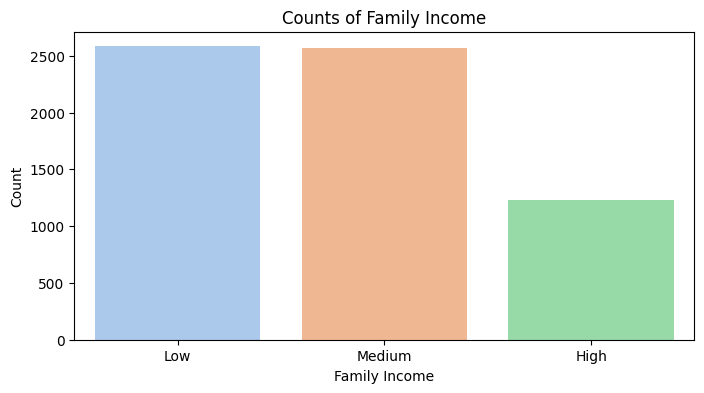

In [50]:
# Family Income
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Family_Income', palette='pastel')
plt.title('Counts of Family Income')
plt.xlabel('Family Income')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\3294999254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Teacher_Quality', palette='pastel')


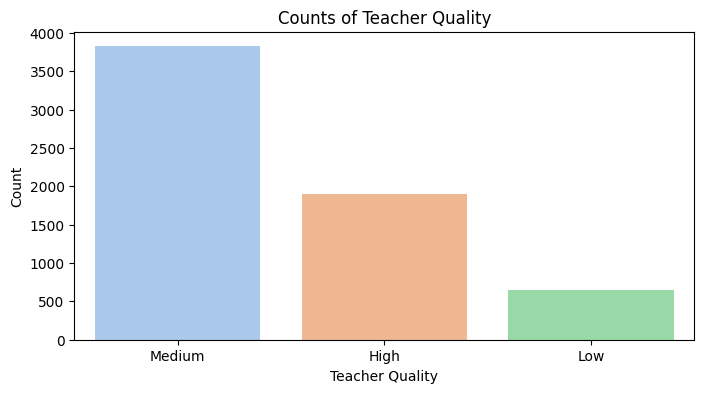

In [54]:
# Teacher Quality
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Teacher_Quality', palette='pastel')
plt.title('Counts of Teacher Quality')
plt.xlabel('Teacher Quality')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\3611726552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='School_Type', palette='pastel')


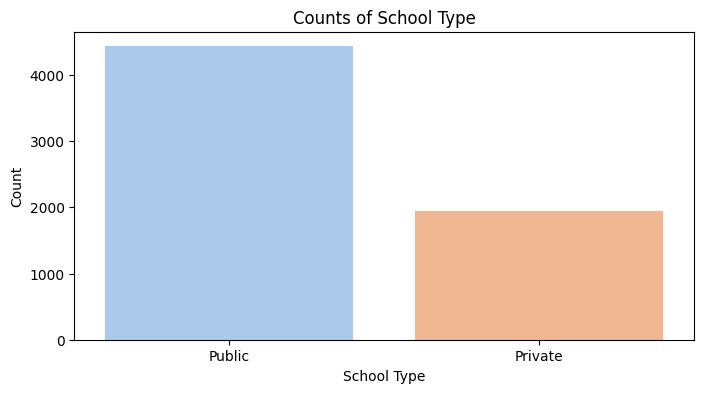

In [55]:
# School Type
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='School_Type', palette='pastel')
plt.title('Counts of School Type')
plt.xlabel('School Type')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\3722826792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Learning_Disabilities', palette='pastel')


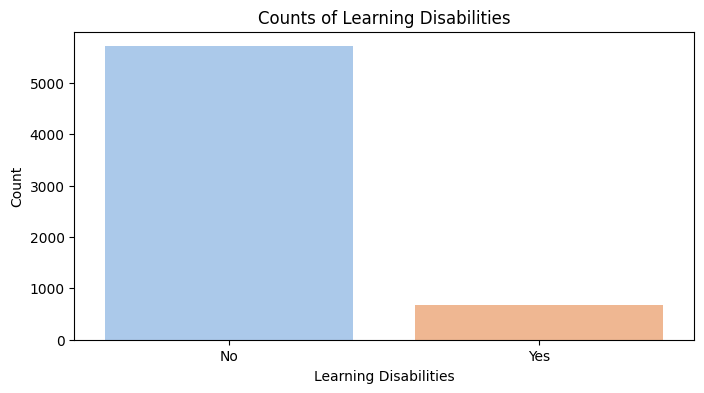

In [56]:
# Learning Disabilities
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Learning_Disabilities', palette='pastel')
plt.title('Counts of Learning Disabilities')
plt.xlabel('Learning Disabilities')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\958140136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Internet_Access', palette='pastel')


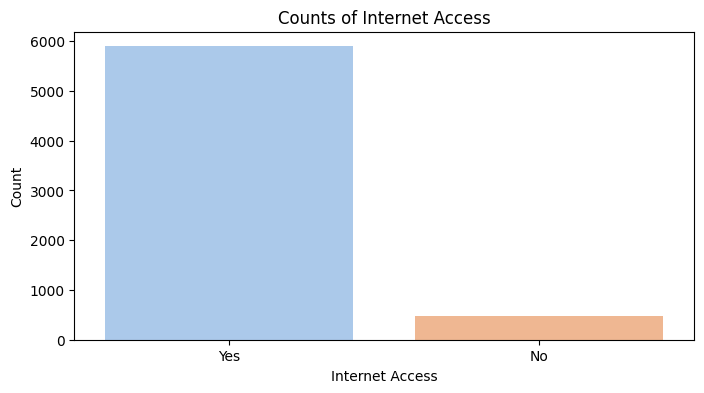

In [57]:
# Internet Access
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Internet_Access', palette='pastel')
plt.title('Counts of Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Count')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19660\4275196246.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Gender', palette='pastel')


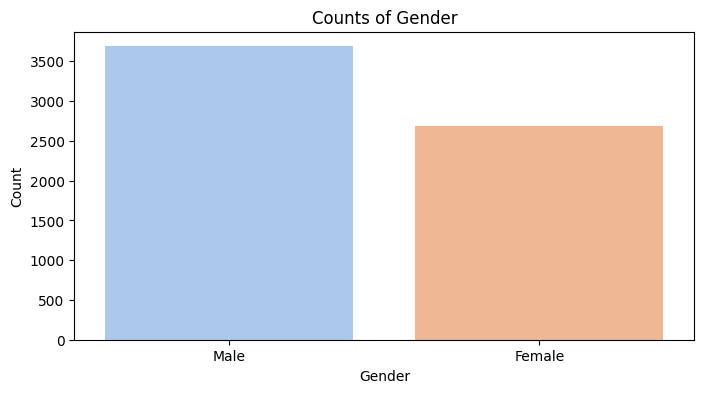

In [58]:
# Gender
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x='Gender', palette='pastel')
plt.title('Counts of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 4.3 Analisis Grup

- **Parental Involvement & Access to Resources**
- **Peer Influence & Motivation Level**
- **Gender & Exam Scores**
- **Extracurricular Activities & Exam Scores**


In [16]:
group1 = data.groupby(['Parental_Involvement', 'Access_to_Resources'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)
group1

,Parental_Involvement,Access_to_Resources,Exam_Score
4,Low,Low,65.295964
7,Medium,Low,66.077042
5,Low,Medium,66.277361
1,High,Low,66.975124
8,Medium,Medium,67.037105
3,Low,High,67.065000
6,Medium,High,67.945720
2,High,Medium,67.995516
0,High,High,69.147601


In [17]:
data.groupby(['Parental_Involvement', 'Parental_Education_Level'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)


,Parental_Involvement,Parental_Education_Level,Exam_Score
4,Low,High School,65.932476
3,Low,College,66.506203
7,Medium,High School,66.749082
5,Low,Postgraduate,67.101887
6,Medium,College,67.164583
1,High,High School,67.784922
8,Medium,Postgraduate,67.943683
0,High,College,68.277778
2,High,Postgraduate,68.670391


In [18]:
data.groupby(['Peer_Influence'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)


,Peer_Influence,Exam_Score
0,Negative,66.582707
1,Neutral,67.215631
2,Positive,67.623433


In [28]:
peer_motivation_crosstab = pd.crosstab(data['Peer_Influence'], data['Motivation_Level'])
peer_motivation_crosstab

Motivation_Level,High,Low,Medium
Peer_Influence,,,
Negative,277,404,649
Neutral,482,707,1306
Positive,518,752,1282


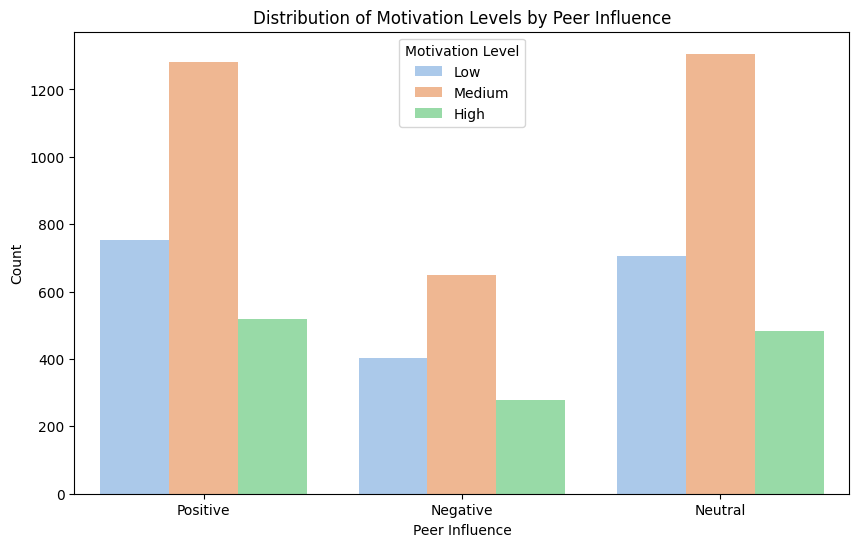

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Peer_Influence', hue='Motivation_Level', palette='pastel')
plt.title('Distribution of Motivation Levels by Peer Influence')
plt.xlabel('Peer Influence')
plt.ylabel('Count')
plt.legend(title='Motivation Level')

In [19]:
grouped = data.groupby(['Motivation_Level'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)
grouped


,Motivation_Level,Exam_Score
1,Low,66.746108
2,Medium,67.338894
0,High,67.743931


In [66]:
data.groupby(['Tutoring_Sessions'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)


,Tutoring_Sessions,Exam_Score
0,0,66.506859
1,1,66.998579
2,2,67.556747
3,3,67.953750
4,4,68.239865
5,5,68.770000
8,8,69.000000
7,7,69.857143
6,6,71.666667


In [21]:
gender_grouped = data.groupby('Gender')['Exam_Score'].mean().reset_index()

gender_grouped

,Gender,Exam_Score
0,Female,67.262179
1,Male,67.235629


C:\Users\User\AppData\Local\Temp\ipykernel_19660\3235446124.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=gender_grouped, x='Gender', y='Exam_Score', palette='pastel')


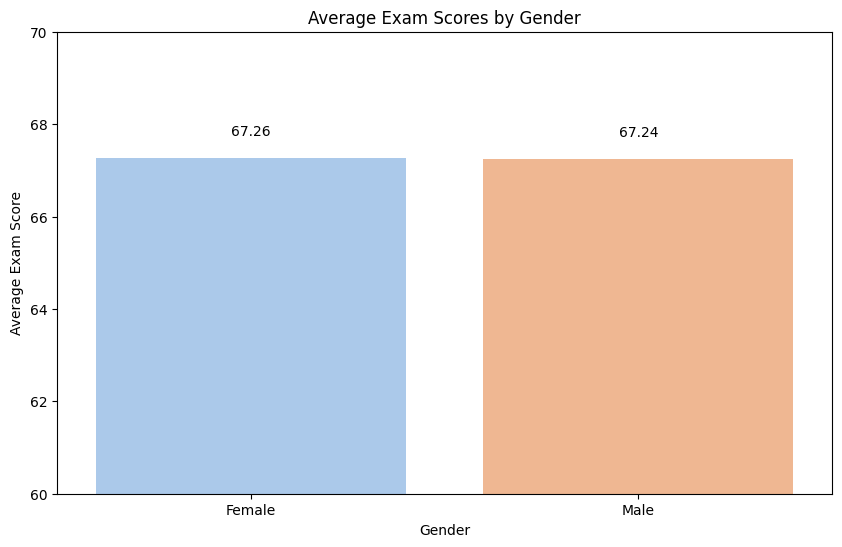

In [44]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=gender_grouped, x='Gender', y='Exam_Score', palette='pastel')

# Add data labels
for index, row in gender_grouped.iterrows():
    barplot.text(index, row['Exam_Score'] + 0.5, round(row['Exam_Score'], 2), color='black', ha="center")

# Adjust y-axis limits
plt.ylim(60, 70)

plt.title('Average Exam Scores by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Exam Score')
plt.show()

In [22]:
extracurricular_grouped = data.groupby('Extracurricular_Activities')['Exam_Score'].mean().reset_index()
extracurricular_grouped

,Extracurricular_Activities,Exam_Score
0,No,66.951770
1,Yes,67.446138


C:\Users\User\AppData\Local\Temp\ipykernel_19660\2125907860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=extracurricular_grouped, x='Extracurricular_Activities', y='Exam_Score', palette='pastel')


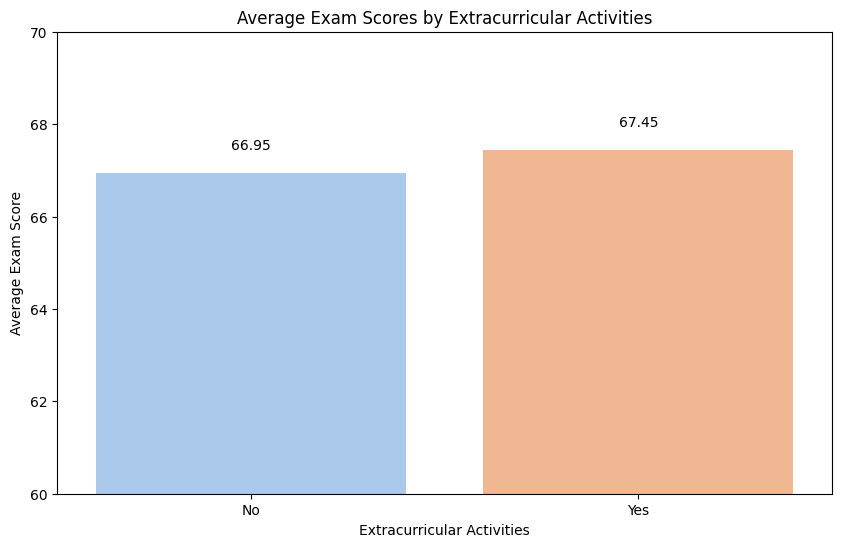

In [46]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=extracurricular_grouped, x='Extracurricular_Activities', y='Exam_Score', palette='pastel')

# Add data labels
for index, row in extracurricular_grouped.iterrows():
    barplot.text(index, row['Exam_Score'] + 0.5, round(row['Exam_Score'], 2), color='black', ha="center")

# Adjust y-axis limits
plt.ylim(60, 70)

plt.title('Average Exam Scores by Extracurricular Activities')
plt.xlabel('Extracurricular Activities')
plt.ylabel('Average Exam Score')
plt.show()

In [65]:
byincome = data.groupby(['Family_Income'])['Exam_Score'].mean().reset_index()
byincome

,Family_Income,Exam_Score
0,High,67.814483
1,Low,66.853215
2,Medium,67.371005


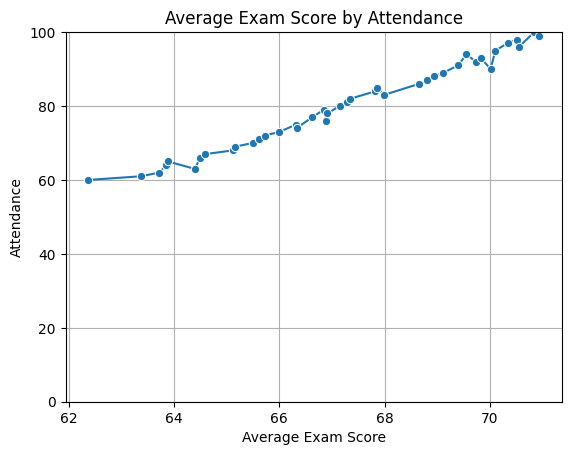

In [24]:
# Group by attendance
kerajinan = data.groupby('Attendance')['Exam_Score'].mean().reset_index()

# Plot
sns.lineplot(data=kerajinan, x='Exam_Score', y='Attendance', marker='o')
plt.title('Average Exam Score by Attendance')
plt.ylabel('Attendance')
plt.xlabel('Average Exam Score')
plt.ylim(0, 100)
plt.grid(True)


In [59]:
economic = data.groupby(['School_Type', 'Teacher_Quality'])['Exam_Score'].mean().reset_index()

# Sort by Exam_Score in ascending order
economic_sorted = economic.sort_values(by='Exam_Score', ascending=True)
economic_sorted

,School_Type,Teacher_Quality,Exam_Score
4,Public,Low,66.667396
1,Private,Low,67.036842
5,Public,Medium,67.042465
2,Private,Medium,67.292704
0,Private,High,67.453311
3,Public,High,67.758935


In [61]:
teacher_quality_by_school = pd.crosstab(data['School_Type'], data['Teacher_Quality'])

# Display the result
teacher_quality_by_school

Teacher_Quality,High,Low,Medium
School_Type,,,
Private,589,190,1165
Public,1315,457,2661


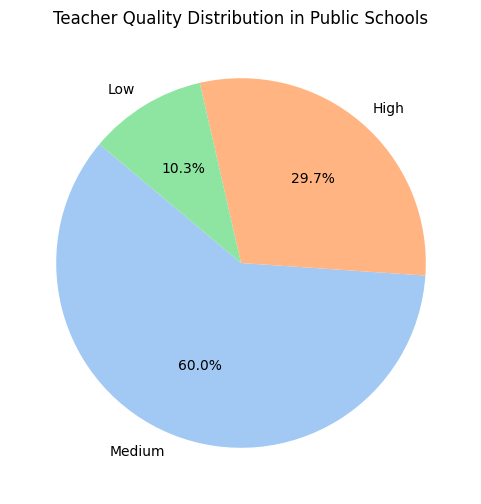

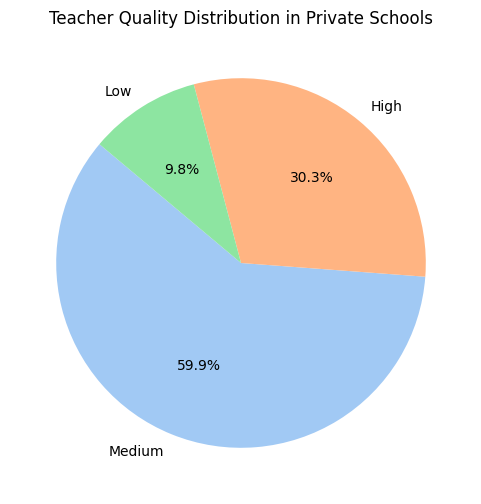

In [63]:
school_types = data['School_Type'].unique()

# Plot pie charts for each school type
for school in school_types:
    plt.figure(figsize=(6, 6))
    subset = data[data['School_Type'] == school]
    teacher_quality_counts = subset['Teacher_Quality'].value_counts()
    plt.pie(teacher_quality_counts, labels=teacher_quality_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title(f'Teacher Quality Distribution in {school} Schools')
    plt.show()

In [34]:
distance_exam_score = data.groupby(['Distance_from_Home'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)
distance_exam_score


,Distance_from_Home,Exam_Score
0,Far,66.498428
1,Moderate,66.969072
2,Near,67.513812


C:\Users\User\AppData\Local\Temp\ipykernel_19660\382958640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=distance_exam_score, x='Distance_from_Home', y='Exam_Score', palette='viridis')


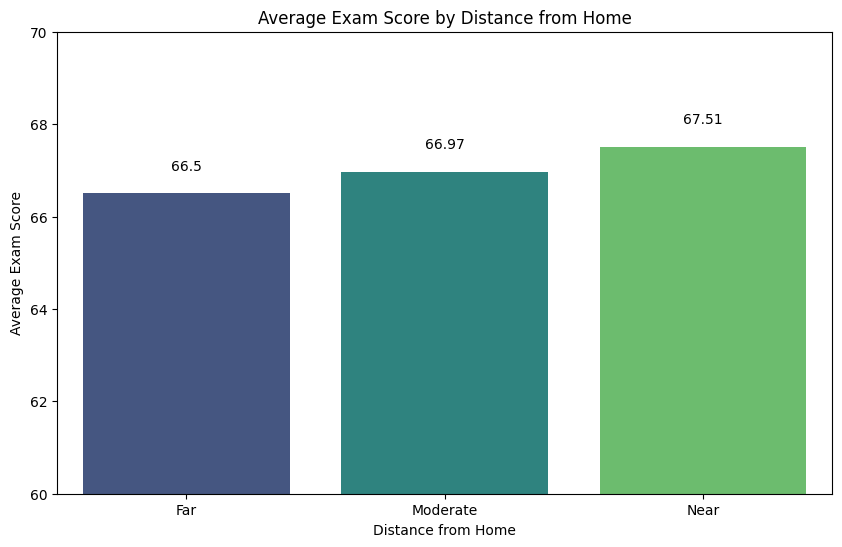

In [35]:
plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=distance_exam_score, x='Distance_from_Home', y='Exam_Score', palette='viridis')
for index, row in distance_exam_score.iterrows():
    barplot.text(index, row['Exam_Score'] + 0.5, round(row['Exam_Score'], 2), color='black', ha="center")
plt.ylim(60, 70)
plt.title('Average Exam Score by Distance from Home')
plt.xlabel('Distance from Home')
plt.ylabel('Average Exam Score')
plt.show()

In [38]:
learning_disabilities_avg = data.groupby(['Learning_Disabilities'])['Exam_Score'].mean().reset_index().sort_values(by='Exam_Score', ascending=True)
learning_disabilities_avg

,Learning_Disabilities,Exam_Score
1,Yes,66.291916
0,No,67.358557


### Hasil Analisis Data

1. **Hubungan antara Kehadiran dan Nilai Siswa:**
   Siswa dengan tingkat kehadiran yang tinggi cenderung memiliki nilai yang lebih baik. Hal ini menunjukkan bahwa konsistensi dalam kehadiran berperan penting dalam pencapaian akademik siswa.

2. **Pengaruh Motivasi terhadap Nilai Siswa:**
   Motivasi yang tinggi memiliki korelasi positif dengan nilai yang lebih baik. Siswa yang termotivasi secara intrinsik dan ekstrinsik menunjukkan performa akademik yang lebih unggul.

3. **Perbandingan Nilai antara Gender:**
   Berdasarkan analisis, tidak ditemukan perbedaan signifikan antara nilai rata-rata siswa laki-laki dan perempuan. Kedua kelompok menunjukkan performa akademik yang relatif setara.

4. **Peran Keterlibatan Orang Tua dan Tingkat Pendidikan Orang Tua:**
   Keterlibatan orang tua dalam pendidikan anak serta tingkat pendidikan orang tua berpengaruh positif terhadap nilai siswa. Semakin tinggi tingkat keterlibatan dan pendidikan orang tua, semakin baik pula hasil akademik yang dicapai siswa.

5. **Pengaruh Pengaruh Teman Sebaya yang Positif:**
   Pengaruh teman sebaya yang positif juga berperan sebagai faktor penting dalam peningkatan nilai siswa. Siswa yang terlibat dalam kelompok sosial yang mendukung dan memotivasi secara akademis menunjukkan hasil yang lebih baik.

6. **Pengaruh Jumlah Sesi Bimbingan terhadap Nilai Ujian:**
   Terdapat tren peningkatan nilai ujian seiring bertambahnya jumlah sesi bimbingan yang diikuti siswa. Siswa yang mengikuti lebih banyak sesi bimbingan cenderung memperoleh nilai ujian yang lebih tinggi, meskipun ada fluktuasi pada sesi ke-6 hingga ke-8 yang menunjukkan variasi hasil.
